In [3]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import RobustScaler, OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import scikit_posthocs as sp
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, accuracy_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Datan kuvailu ja preprosessointi
## 1.1 Yleiset perushavainnot

In [4]:
#Määritetään tyypit kaikille muuttujille

df = pd.read_csv('puut1.csv', 
                 index_col=0,
                 dtype={
                   "length": np.float64,
                   "diameter": np.float64,
                   "cones": np.int64,
                   "leaves": np.int64,
                   "bark_thickness": np.float64,
                   "seed_size": np.float64,
                   "fungi_present": np.bool,
                   "color_guess": np.object_,
                   "soil_pH": np.float64,
                   "collector_id": np.float64,
                   "collector_guess": np.float64,
                   }, 
                   na_values="*"
                   )

#Jaetaan data luokkiin

numeric_vars = ["length", "diameter", "cones", "leaves", "bark_thickness", "seed_size", "soil_pH"]
categoric_vars = ["fungi_present", "color_guess"]
researcher_vars = ["collector_guess", "collector_id"]

In [5]:
#Datan yleiset perushavainnot

print(f"Rivien määrä: {df.shape[0]}")
print(f"Numeeristen muuttujien määrä: {len(numeric_vars)}")
print(f"Kategoristen muuttujien määrä: {len(categoric_vars)}")

#Datan eheyden tarkistaminen

print(f"\nPuuttuvien arvojen määrä: {df.isnull().sum().sum()}")
print(f"Duplikaatti-arvojen määrä: {df.duplicated().sum()}")

Rivien määrä: 300
Numeeristen muuttujien määrä: 7
Kategoristen muuttujien määrä: 2

Puuttuvien arvojen määrä: 0
Duplikaatti-arvojen määrä: 20


## 1.2 Numeeristen muuttujien attribuutit

       length  diameter   cones    leaves  bark_thickness  seed_size  soil_pH
count  300.00    300.00  300.00    300.00          300.00     300.00   300.00
mean   267.45    115.53   87.84  10689.06            1.16       1.00     7.99
std     78.86     24.84   58.51   5691.38            0.27       0.02     1.04
min     69.08     73.96  -10.00   1067.00            0.62       0.83     4.85
25%    207.40     98.31   35.75   5720.00            0.98       1.00     7.32
50%    289.56    105.57   85.50  10631.00            1.09       1.00     8.02
75%    306.41    130.83  131.25  15620.50            1.31       1.00     8.63
max    516.90    214.82  199.00  19956.00            2.25       1.16    11.85

length              289.565000
diameter            105.575000
cones                85.500000
leaves            10631.000000
bark_thickness        1.090000
seed_size             1.000088
soil_pH               8.020000
dtype: float64 

length          Outliers: 6
diameter        Outliers: 5
cones  

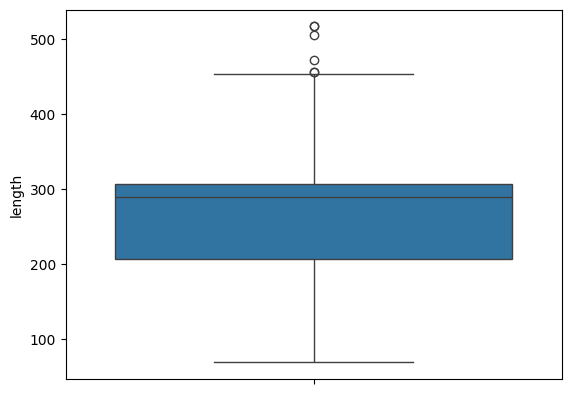

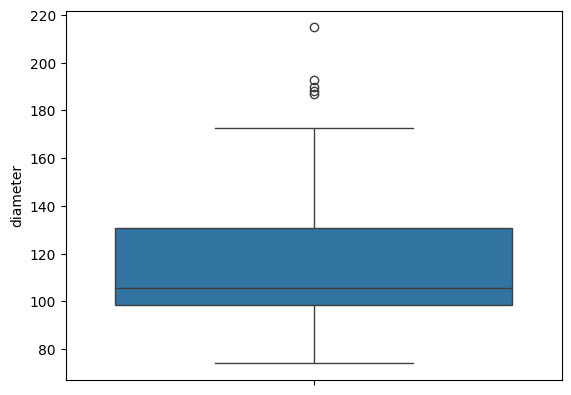

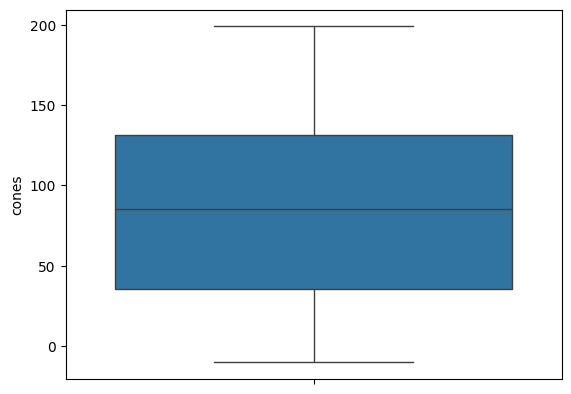

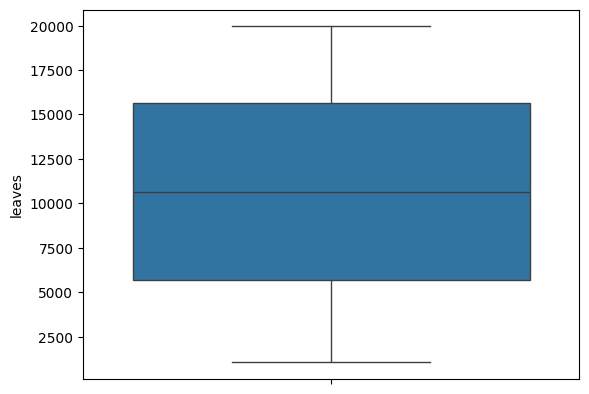

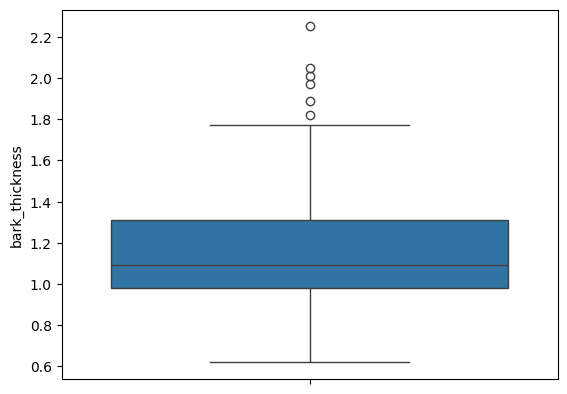

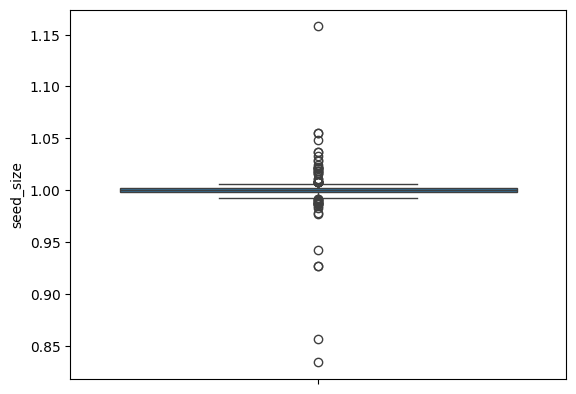

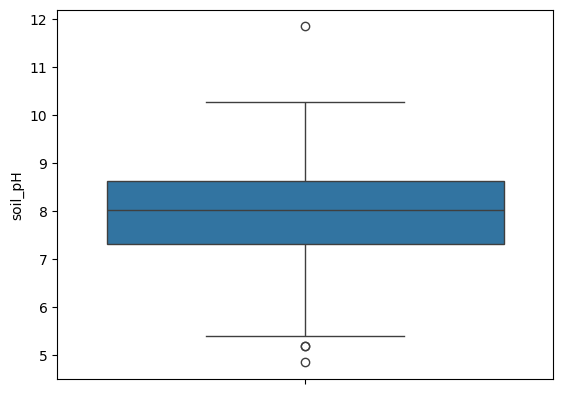

In [6]:
print(f"{df[numeric_vars].describe().round(2)}\n")
print(df[numeric_vars].median(), "\n")

for col in numeric_vars:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  print(f"{col:<15} Outliers: {len(outliers)}")


for col in numeric_vars:
  sns.boxplot(y = df[col], orient="v")
  plt.show()

## 1.3 Kategoristen muuttujien attribuutit

In [7]:
print(f"{df[categoric_vars].describe().round(2)}\n")
print(df[categoric_vars].value_counts())

       fungi_present color_guess
count            300         300
unique             2           5
top            False    lightish
freq             154          76

fungi_present  color_guess
False          mid-green      41
               lightish       39
True           lightish       37
False          dark           34
True           light          31
               mid-green      29
               dark           27
False          light          26
True           darkish        22
False          darkish        14
Name: count, dtype: int64


In [8]:
"""
df['fungi_present_num'] = df['fungi_present'].replace([False, True], [0, 1])
df['color_guess_num'] = df['color_guess'].replace(
  ['dark', 'light', 'mid-green', 'lightish', 'darkish'],
  [0, 4, 2, 3, 1]
  )

numeric_categorical = ["fungi_present_num","color_guess_num"]
"""

'\ndf[\'fungi_present_num\'] = df[\'fungi_present\'].replace([False, True], [0, 1])\ndf[\'color_guess_num\'] = df[\'color_guess\'].replace(\n  [\'dark\', \'light\', \'mid-green\', \'lightish\', \'darkish\'],\n  [0, 4, 2, 3, 1]\n  )\n\nnumeric_categorical = ["fungi_present_num","color_guess_num"]\n'

## 1.4 Datan eheyden varmistaminen

In [9]:
df.cones = df.cones.abs()
df = df.drop_duplicates()

## 1.5 Muuttujien väliset suhteet

In [10]:
#Normaalijakauma
shapiro_test = stats.shapiro(df[numeric_vars], axis=0)
print(f'P-arvot numeeriselle datalle:')
for index, row in enumerate(shapiro_test.pvalue):
  print(f'{df[numeric_vars].columns[index]:<15} {row:<8.3} {"< 0.05" if row < 0.05  else "> 0.05"}')

P-arvot numeeriselle datalle:
length          1.42e-07 < 0.05
diameter        1.86e-14 < 0.05
cones           3.04e-08 < 0.05
leaves          1.04e-08 < 0.05
bark_thickness  5.77e-09 < 0.05
seed_size       2.18e-28 < 0.05
soil_pH         0.442    > 0.05


In [27]:
from scipy.stats import spearmanr, chi2_contingency, f_oneway
#Numeeristen muuttujien korrelaatio
for c1 in numeric_vars:
    for c2 in numeric_vars:
        if c1 < c2:
            corr, p = spearmanr(df[c1], df[c2])
            print(f"{c1:<15} vs {c2:<10}: r={corr:<5.2f}, p={p:.4f}")

length          vs seed_size : r=-0.00, p=0.9542
length          vs soil_pH   : r=-0.05, p=0.4230
diameter        vs length    : r=0.18 , p=0.0024
diameter        vs leaves    : r=-0.00, p=0.9361
diameter        vs seed_size : r=-0.05, p=0.3646
diameter        vs soil_pH   : r=-0.04, p=0.4772
cones           vs length    : r=0.05 , p=0.4133
cones           vs diameter  : r=0.07 , p=0.2427
cones           vs leaves    : r=0.04 , p=0.5169
cones           vs seed_size : r=0.07 , p=0.2380
cones           vs soil_pH   : r=0.07 , p=0.2462
leaves          vs length    : r=-0.07, p=0.2332
leaves          vs seed_size : r=-0.10, p=0.1068
leaves          vs soil_pH   : r=0.01 , p=0.8883
bark_thickness  vs length    : r=0.16 , p=0.0059
bark_thickness  vs diameter  : r=0.86 , p=0.0000
bark_thickness  vs cones     : r=0.05 , p=0.3614
bark_thickness  vs leaves    : r=0.03 , p=0.6566
bark_thickness  vs seed_size : r=-0.10, p=0.0797
bark_thickness  vs soil_pH   : r=0.00 , p=0.9409
seed_size       vs s

In [12]:
#Kategoristen muuttujien korrelaatio
for c1 in categoric_vars:
    for c2 in categoric_vars:
        if c1 < c2:
            ct = pd.crosstab(df[c1], df[c2])
            chi2, p, _, _ = chi2_contingency(ct)
            print(f"{c1:<15} vs {c2:<15}: chi2={chi2:<5.2f}, p={p:.4f}")

color_guess     vs fungi_present  : chi2=3.77 , p=0.4385


In [28]:
from scipy.stats import kruskal
import scikit_posthocs as sp
import pandas as pd

results = []

for num in numeric_vars:
    for cat in categoric_vars:

        temp = df[[num, cat]]
        groups = [g[num].values for _, g in temp.groupby(cat)]

        stat, p = kruskal(*groups)

        if True:
         results.append({
            'numeric'    : num,
            'categorical': cat,
            'H_stat'     : round(stat, 4),
            'p_value'    : round(p, 4),
            'significant': 'Yes' if p < 0.05 else 'No'
        })   

# Summary Table
results_df = pd.DataFrame(results).sort_values('p_value')
print(results_df.to_string(index=False))

       numeric   categorical  H_stat  p_value significant
      diameter fungi_present 14.0574   0.0002         Yes
bark_thickness fungi_present 12.4700   0.0004         Yes
bark_thickness   color_guess  8.1484   0.0863          No
     seed_size fungi_present  1.2201   0.2693          No
        length fungi_present  0.9730   0.3239          No
     seed_size   color_guess  4.5791   0.3333          No
       soil_pH   color_guess  3.6749   0.4518          No
         cones   color_guess  3.6287   0.4586          No
      diameter   color_guess  2.7884   0.5938          No
        length   color_guess  2.2875   0.6830          No
         cones fungi_present  0.1440   0.7043          No
       soil_pH fungi_present  0.0576   0.8104          No
        leaves   color_guess  0.9785   0.9130          No
        leaves fungi_present  0.0001   0.9935          No


# 2 Analyysi

In [14]:
df.columns

Index(['length', 'diameter', 'cones', 'leaves', 'bark_thickness', 'seed_size',
       'fungi_present', 'color_guess', 'soil_pH', 'collector_id',
       'collector_guess'],
      dtype='str')

In [15]:
feature_1 = ['length', 'diameter', 'bark_thickness']
feature_2 = ['fungi_present', 'color_guess']
feature_3 = ['cones', 'leaves', 'seed_size']

In [16]:
import itertools

combinations = list(itertools.product(feature_1, feature_2, feature_3))

In [18]:
import gower

gower_matrices = {}

for combination in combinations:
  subset = df[list(combination)]
  gower_matrices[combination] = gower.gower_matrix(subset)

In [20]:
import hdbscan

cluster_sizes = [2, 3, 4, 5]
sample_range = [1, 2, 3]

results = []

for combination in combinations:
  for cs in cluster_sizes:
    for sr in sample_range:
      clusterer = hdbscan.HDBSCAN(
        min_cluster_size=cs,
        min_samples = sr,
        metric='precomputed'
      )
      labels = clusterer.fit_predict(gower_matrices[combination].astype(np.float64))

      n_clusters = len(set(labels) - {-1})
      n_noise = (labels == -1).sum()

      if n_clusters >= 2:
        mask = labels != -1
        if len(set(labels[mask])) >= 2 and mask.sum() > n_clusters:
            score = silhouette_score(
                gower_matrices[combination][mask][:, mask],
                labels[mask],
                metric='precomputed'
            )
            results.append({
                'features': combination,
                'method': 'hdbscan',
                'min_cluster_size': cs,
                'min_samples': sr,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'labels': labels,
                # HDBSCAN provides its own probabilities
                'silhouette': round(score, 4)
            })


In [21]:
best = pd.DataFrame(results).sort_values('silhouette', ascending=False).head(1)

In [22]:
print(gower_matrices[best['features'].values[0]])

[[0.         0.13215631 0.04340047 ... 0.4590446  0.4305358  0.10126327]
 [0.13215631 0.         0.13267651 ... 0.33977836 0.53516686 0.04421699]
 [0.04340047 0.13267651 0.         ... 0.46187016 0.40249032 0.10178348]
 ...
 [0.4590446  0.33977836 0.46187016 ... 0.         0.19538847 0.37429306]
 [0.4305358  0.53516686 0.40249032 ... 0.19538847 0.         0.5042738 ]
 [0.10126327 0.04421699 0.10178348 ... 0.37429306 0.5042738  0.        ]]


In [23]:
from sklearn.manifold import MDS, TSNE

def get_2d_embeddings(dist_matrix):
    """Generate multiple 2D embeddings from a distance matrix."""

    # --- MDS (preserves global distances well) ---
    mds = MDS(
        n_components=2,
        dissimilarity='precomputed',
        random_state=42,
        normalized_stress='auto'
    )
    coords_mds = mds.fit_transform(dist_matrix)

    # --- t-SNE (preserves local neighborhoods) ---
    tsne = TSNE(
        n_components=2,
        metric='precomputed',
        random_state=42,
        perplexity=min(5, len(dist_matrix) - 1),  # adjust for small datasets
        init='random'
    )
    coords_tsne = tsne.fit_transform(dist_matrix)

    return coords_mds, coords_tsne

coords_mds, coords_tsne = get_2d_embeddings(gower_matrices[best['features'].values[0]])

/home/asteer/data/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/home/asteer/data/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/asteer/data/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


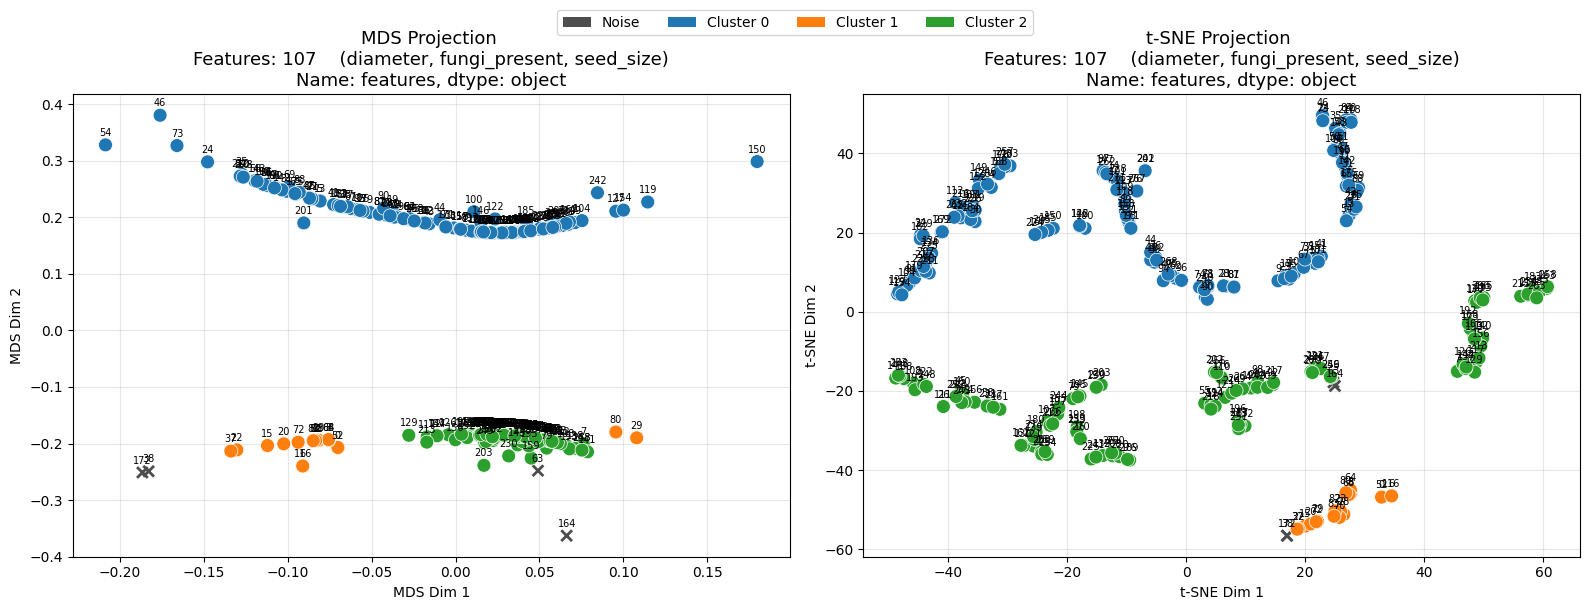

In [26]:
from matplotlib import cm

def plot_clusters_2d(coords_mds, coords_tsne, labels, title_suffix=""):
    """Side-by-side MDS and t-SNE scatter plots."""
    unique_labels = sorted(set(labels))
    # Colormap: noise (-1) is black, clusters get distinct colors
    palette = cm.tab10(np.linspace(0, 1, max(len(unique_labels), 10)))
    color_map = {}
    cluster_idx = 0
    for label in unique_labels:
        if label == -1:
            color_map[label] = (0.3, 0.3, 0.3, 1.0)  # grey for noise
        else:
            color_map[label] = palette[cluster_idx]
            cluster_idx += 1

    colors = [color_map[l] for l in labels]
    noise_mask = labels == -1

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, coords, method in zip(axes, [coords_mds, coords_tsne], ['MDS', 't-SNE']):
        # Plot cluster points
        ax.scatter(
            coords[~noise_mask, 0], coords[~noise_mask, 1],
            c=[colors[i] for i in range(len(labels)) if not noise_mask[i]],
            s=100, edgecolors='white', linewidth=0.5, zorder=3
        )
        # Plot noise points
        if noise_mask.any():
            ax.scatter(
                coords[noise_mask, 0], coords[noise_mask, 1],
                c=[colors[i] for i in range(len(labels)) if noise_mask[i]],
                s=60, marker='x', linewidth=2, zorder=2, label='Noise'
            )

        # Annotate point indices
        for i, (x, y) in enumerate(coords):
            ax.annotate(str(i), (x, y), fontsize=7, ha='center', va='bottom',
                        xytext=(0, 5), textcoords='offset points')

        ax.set_title(f'{method} Projection {title_suffix}', fontsize=13)
        ax.set_xlabel(f'{method} Dim 1')
        ax.set_ylabel(f'{method} Dim 2')
        ax.grid(True, alpha=0.3)

    # Shared legend
    from matplotlib.patches import Patch
    legend_elements = []
    for label in unique_labels:
        name = 'Noise' if label == -1 else f'Cluster {label}'
        legend_elements.append(Patch(facecolor=color_map[label], label=name))
    fig.legend(handles=legend_elements, loc='upper center',
               ncol=len(unique_labels), bbox_to_anchor=(0.5, 1.02), fontsize=10)

    plt.tight_layout()
    plt.show()

plot_clusters_2d(
    coords_mds, coords_tsne,
    best['labels'].values[0],
    title_suffix=f"\nFeatures: {best['features']}"
)